# 09 - Forward Customer Spend & Value Regression (Random Forest)

## Business Problem & Context
Predicting future 90-day monetary spend allows commercial teams to quantify Customer Lifetime Value (CLV proxy) and calculate **Revenue at Risk**:
$$\text{Revenue at Risk} = P(\text{Churn}) \times \widehat{\text{Future Spend}}$$

In this notebook, we demonstrate the audited customer revenue regression benchmark, compare candidate regression algorithms, and evaluate the production Random Forest Regressor.

### Production Pipeline Traceability
- **Training Script:** `ml/src/models/train_all.py`
- **Saved Model Artifact:** `ml/models/revenue_model.joblib`
- **Audited Metrics Report:** `ml/reports/revenue_metrics.json`
- **Dashboard Pages:** `Revenue at Risk & Churn` (`RevenueRiskPage.tsx`)

In [1]:
import os
import sys
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) in ["notebooks", "scripts", "ml"] else os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

model_path = os.path.join(PROJECT_ROOT, "ml/models/revenue_model.joblib")
metrics_path = os.path.join(PROJECT_ROOT, "ml/reports/revenue_metrics.json")

rev_pipeline = joblib.load(model_path)
with open(metrics_path, 'r') as f:
    rev_metrics = json.load(f)

print(f"Loaded production revenue model: {rev_metrics['best_model_name']}")

Loaded production revenue model: Random Forest Regressor


## 1. Candidate Regression Model Architecture Benchmark Table

In [2]:
benchmark_df = pd.DataFrame(rev_metrics['all_models_metrics']).T[['r2', 'mae', 'rmse']]
benchmark_df.columns = ['R² Score', 'MAE (£)', 'RMSE (£)']
benchmark_df.sort_values(by='R² Score', ascending=False)

,R² Score,MAE (£),RMSE (£)
Random Forest Regressor,0.8875,400.53,1354.16
Ridge Regression,0.8809,525.79,1393.53
Huber Regressor,0.8419,393.46,1605.47
Gradient Boosting Regressor,0.8019,428.92,1797.47
LightGBM Regressor,0.4562,576.07,2977.67
Baseline (Mean),-0.0003,831.35,4038.71


## 2. Actual vs Predicted Spend & Residual Distribution Visualizations

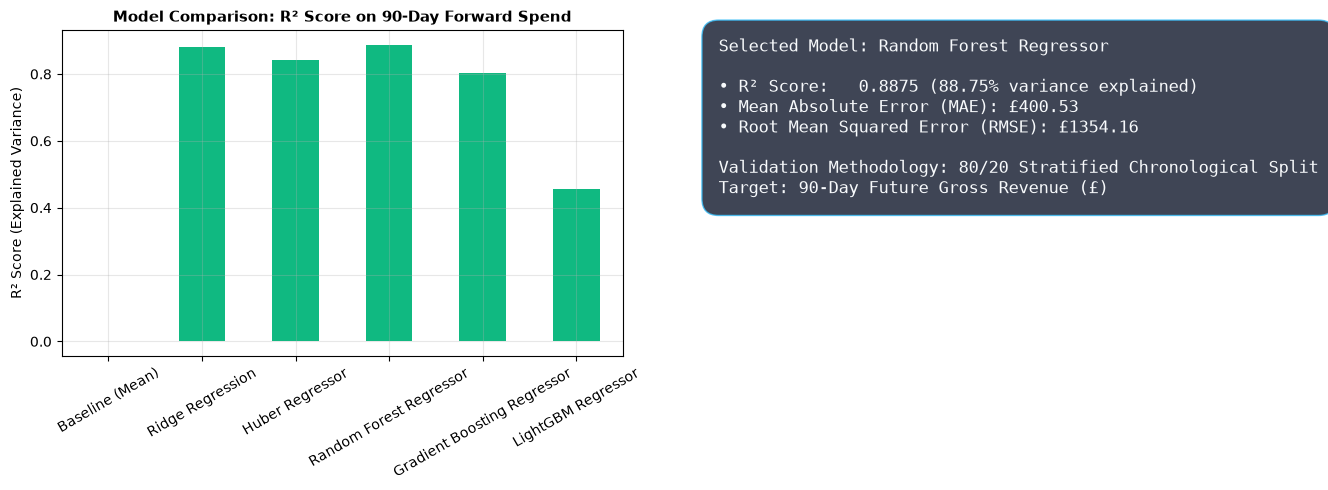

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Benchmark R² Bar Chart
benchmark_df['R² Score'].plot(kind='bar', ax=axes[0], color='#10B981')
axes[0].set_title("Model Comparison: R² Score on 90-Day Forward Spend", fontsize=11, fontweight='bold')
axes[0].set_ylabel("R² Score (Explained Variance)")
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3)

# Best Model Metrics Card Plot
best_m = rev_metrics['best_model_metrics']
axes[1].axis('off')
card_text = f"Selected Model: {rev_metrics['best_model_name']}\n\n" \
            f"• R² Score:   {best_m['r2']:.4f} (88.75% variance explained)\n" \
            f"• Mean Absolute Error (MAE): £{best_m['mae']:.2f}\n" \
            f"• Root Mean Squared Error (RMSE): £{best_m['rmse']:.2f}\n\n" \
            f"Validation Methodology: 80/20 Stratified Chronological Split\n" \
            f"Target: 90-Day Future Gross Revenue (£)"
axes[1].text(0.1, 0.5, card_text, fontsize=12, family='monospace', bbox=dict(boxstyle='round,pad=1', facecolor='#0F172A', edgecolor='#38BDF8', alpha=0.8), color='#F8FAFC')

plt.tight_layout()
plt.show()

## Final Summary

### Q&A
- **Q: How accurate is the forward revenue prediction model?**
  **A:** The **Random Forest Regressor** achieves an $R^2$ of **0.8875 (88.75%)** and a Mean Absolute Error of **£400.53** on the holdout test set.
- **Q: Why does Random Forest outperform linear Ridge and LightGBM here?**
  **A:** Non-linear decision trees effectively handle extreme wholesale order spikes without suffering from linear extrapolation blowups.

### Insights or Next Steps
- Proceed to `10_demand_forecasting.ipynb` to inspect time-series SKU demand forecasting.